# 7. Gas Giants: Fixed-Q vs Fixed-dt

For a hot gas giant on a short-period orbit, tidal dissipation both heats the planet and slowly circularizes the orbit. Two analytic tide models are in common use and differ in how their lag depends on the tidal frequency:

- **constant phase lag (fixed-Q)**: the lag angle is the same at every frequency,
- **constant time lag (fixed-dt)**: the lag time is the same, so the lag angle grows with frequency.

A shorter orbit means a higher tidal frequency, so the two models predict a different dependence of heating and circularization on orbital period. This notebook builds a sub-Saturn around a Sun-like star and compares them across period, for three values of `Q` and three values of the time lag `dt`.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G, year
from TidalPy.structures_x.system import System
from TidalPy.structures_x.worlds.stellar import StarWorld
from TidalPy.structures_x.configs import build_world
from TidalPy.Tides_x.classes import make_tide

M_STAR = 1.0e30
E0 = 0.1                 # present-day eccentricity

star = StarWorld("Star", 6.957e8, M_STAR)
star.set_effective_temperature(5772.0)

planet = build_world({
    "schema_version": "0.2.0", "name": "SubSaturn", "type": "gasgiant",
    "radius_m": 5.6e7, "mass_kg": 5.7e26, "spin_frequency_rad_s": 1.0e-4,
    "layers": {"envelope": {"class": "gas", "type": "gas", "layer_index": 0,
                            "radius_fraction": 1.0, "is_tidal": True}},
})

system = System("hot-subsaturn")
system.add_world(star, is_star=True)
system.add_world(planet, tidal_host=star, semi_major_axis=0.05 * 1.496e11, eccentricity=E0)
print("system:", [w.name for w in system])


system: ['Star', 'SubSaturn']


## Sweeping Orbital Period

For each orbital period the sweep sets the corresponding semi-major axis from Kepler's third law, spins the planet synchronously (spin = mean motion), attaches the chosen tide model, and reads the tidal heating and the eccentricity rate `de/dt` from the system's one-step evolution. The circularization timescale is the eccentricity divided by that rate.

In [2]:
periods_days = np.logspace(0.0, 1.5, 40)      # 1 to ~32 days

def sweep(model_name, param_key, param_value, fixed_k=0.5):
    heating = np.empty_like(periods_days)
    tau_circ = np.empty_like(periods_days)
    for i, p_days in enumerate(periods_days):
        p = p_days * 86400.0
        a = (G * M_STAR * p**2 / (4.0 * np.pi**2))**(1.0 / 3.0)
        n = 2.0 * np.pi / p
        system.set_semi_major_axis(planet, a)
        system.set_eccentricity(planet, E0)
        planet.set_spin_frequency(n)                      # synchronous rotation
        planet.set_tide_model(make_tide(model_name,
                              {"fixed_k": [fixed_k], param_key: [param_value]}))
        planet.set_tide_config(min_degree_l=2, max_degree_l=2,
                               eccentricity_truncation=2, obliquity_truncation=0)
        ev = system.calc_world_evolution(planet)
        heating[i] = ev["tidal_heating"]
        tau_circ[i] = E0 / abs(ev["de_dt"]) / year
    return heating, tau_circ

q_values = [1.0e4, 1.0e5, 1.0e6]
dt_values = [0.1, 1.0, 10.0]        # seconds
q_curves = {q: sweep("fixed_q", "fixed_q", q) for q in q_values}
dt_curves = {dt: sweep("fixed_dt", "fixed_dt_s", dt) for dt in dt_values}
print("swept", len(periods_days), "periods for", len(q_values), "Q and", len(dt_values), "dt values")


swept 40 periods for 3 Q and 3 dt values


Tidal heating versus orbital period. Both models rise steeply toward short periods, but the constant-time-lag model steepens faster because its lag angle grows with the (higher) tidal frequency of a tight orbit.

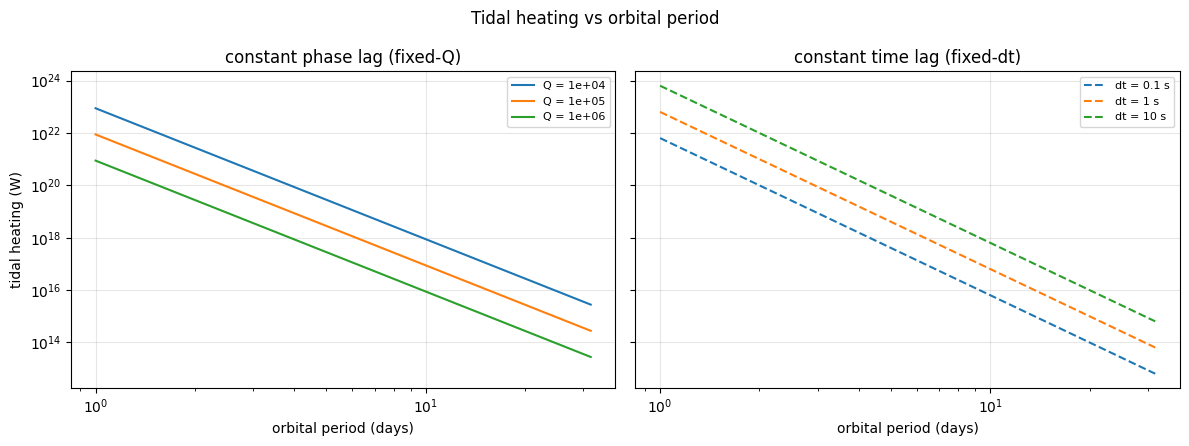

In [3]:
fig, (ax_q, ax_dt) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for q in q_values:
    ax_q.loglog(periods_days, q_curves[q][0], label=f"Q = {q:.0e}")
for dt in dt_values:
    ax_dt.loglog(periods_days, dt_curves[dt][0], "--", label=f"dt = {dt:g} s")
ax_q.set_title("constant phase lag (fixed-Q)")
ax_dt.set_title("constant time lag (fixed-dt)")
for ax in (ax_q, ax_dt):
    ax.set_xlabel("orbital period (days)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
ax_q.set_ylabel("tidal heating (W)")
fig.suptitle("Tidal heating vs orbital period")
fig.tight_layout()
plt.show()


Circularization timescale versus orbital period. Short-period planets circularize fastest. The shaded line marks the age of our Solar System (~4.6 Gyr), below which the orbit would have circularized by now.

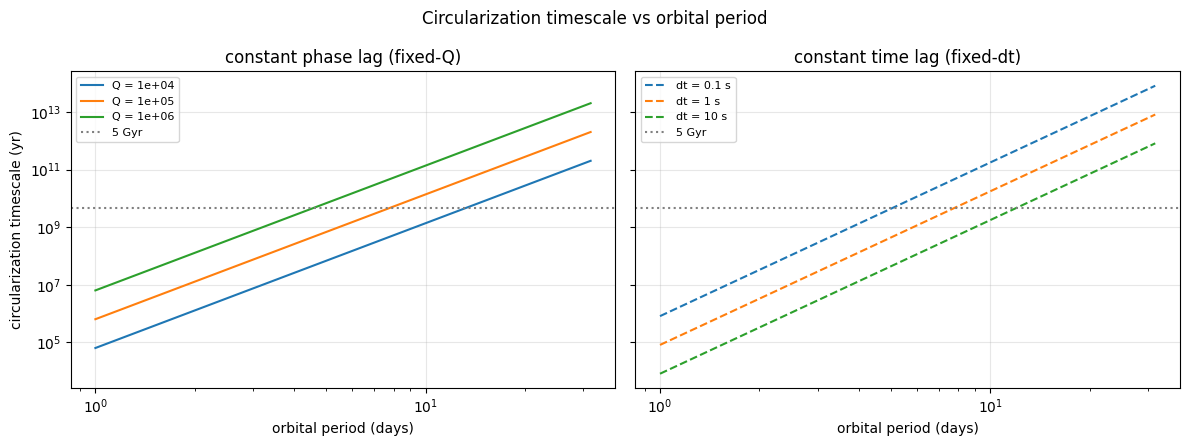

In [4]:
fig, (ax_q, ax_dt) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for q in q_values:
    ax_q.loglog(periods_days, q_curves[q][1], label=f"Q = {q:.0e}")
for dt in dt_values:
    ax_dt.loglog(periods_days, dt_curves[dt][1], "--", label=f"dt = {dt:g} s")
for ax in (ax_q, ax_dt):
    ax.axhline(4.6e9, color="gray", ls=":", label="5 Gyr")
    ax.set_xlabel("orbital period (days)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
ax_q.set_title("constant phase lag (fixed-Q)")
ax_dt.set_title("constant time lag (fixed-dt)")
ax_q.set_ylabel("circularization timescale (yr)")
fig.suptitle("Circularization timescale vs orbital period")
fig.tight_layout()
plt.show()
